In [3]:
class Solution:
    def solve(self, i, j, matrix, r, c):

        if j < 0 or j >= c:
            return float('inf')

        if i == 0:
            return matrix[i][j]

        up = matrix[i][j] + self.solve(i - 1, j, matrix, r, c)
        left = matrix[i][j] + self.solve(i - 1, j - 1, matrix, r, c)
        right = matrix[i][j] + self.solve(i - 1, j + 1, matrix, r, c)

        return min(left, up, right)
        

    def minFallingPathSum(self, matrix):
        r = len(matrix)
        c = len(matrix[0])

        mini = float('inf')

        for j in range(c):
            mini = min(mini,self.solve(r-1,j,matrix,r,c))
        
        return mini

matrix = [[2,1,3],[6,5,4],[7,8,9]]
obj = Solution()
obj.minFallingPathSum(matrix)

13

In [5]:
# memo
from typing import List
class Solution:
    def solve(self, i, j, matrix, r, c,dp):
        if j < 0 or j >= c:
            return float('inf')

        if i == 0:
            return matrix[i][j]

        if dp[i][j] != -1:
            return dp[i][j]

        up = matrix[i][j] + self.solve(i - 1, j, matrix, r, c,dp)
        left = matrix[i][j] + self.solve(i - 1, j - 1, matrix, r, c,dp)
        right = matrix[i][j] + self.solve(i - 1, j + 1, matrix, r, c,dp)

        dp[i][j] = min(left, up, right)
        return dp[i][j]

    def minFallingPathSum(self, matrix: List[List[int]]) -> int:
        r = len(matrix)
        c = len(matrix[0])

        mini = float('inf')

        dp = [[-1 for _ in range(r)] for _ in range(c)]

        for j in range(c):
            mini = min(mini,self.solve(r-1,j,matrix,r,c,dp))
        return mini

In [ ]:
# TODO:Tabulation
from typing import List

class Solution:
    def minFallingPathSum(self, matrix: List[List[int]]) -> int:
        rows = len(matrix)
        cols = len(matrix[0])

        dp = [[None for _ in range(cols)] for _ in range(rows)]

        # First row
        for j in range(cols):
            dp[0][j] = matrix[0][j]

        # Remaining rows
        for i in range(1, rows):
            for j in range(cols):

                # Left diagonal
                if j == 0:
                    left = float('inf')
                else:
                    left = matrix[i][j] + dp[i - 1][j - 1]

                # Up
                up = matrix[i][j] + dp[i - 1][j]

                # Right diagonal
                if j == cols - 1:
                    right = float('inf')
                else:
                    right = matrix[i][j] + dp[i - 1][j + 1]

                dp[i][j] = min(left, up, right)

        # Minimum value in last row
        mini = float('inf')

        for j in range(cols):
            mini = min(mini, dp[rows - 1][j])

        return mini


matrix = [[2, 1, 3],
          [6, 5, 4],
          [7, 8, 9]]

obj = Solution()
print(obj.minFallingPathSum(matrix))

13


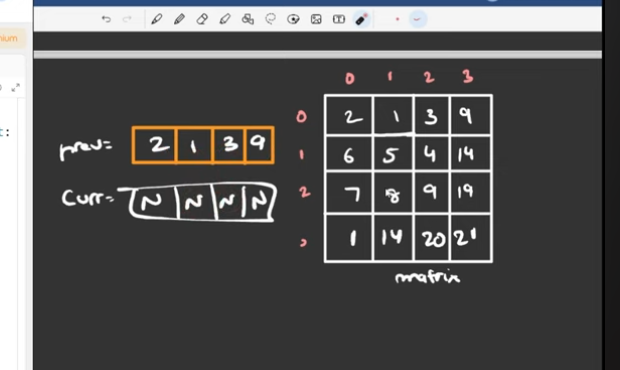
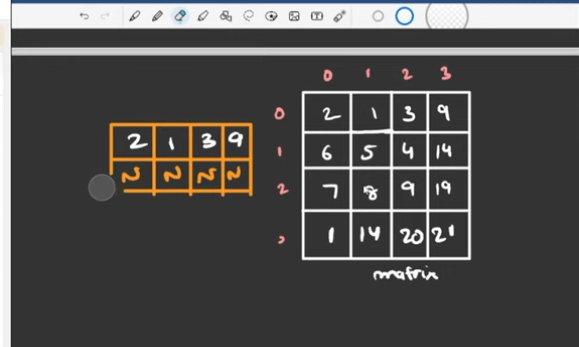

In [10]:
# TODO:Tabulation + Space Optimization
from typing import List

class Solution:
    def minFallingPathSum(self, matrix: List[List[int]]) -> int:
        rows = len(matrix)
        cols = len(matrix[0])

        prev = [None for _ in range(cols)]

        # First row
        for j in range(cols):
            prev[j] = matrix[0][j]

        # Remaining rows
        for i in range(1, rows):
            curr = [None] * cols
            for j in range(cols):

                # Left diagonal
                if j == 0:
                    left = float('inf')
                else:
                    left = matrix[i][j] + prev[j - 1]

                # Up
                up = matrix[i][j] + prev[j]

                # Right diagonal
                if j == cols - 1:
                    right = float('inf')
                else:
                    right = matrix[i][j] + prev[j + 1]

                curr[j] = min(left, up, right)

            prev = curr
    
        # Minimum value in last row
        mini = float('inf')

        for j in range(cols):
            mini = min(mini, prev[j])

        return mini


matrix = [[2, 1, 3],
          [6, 5, 4],
          [7, 8, 9]]

obj = Solution()
print(obj.minFallingPathSum(matrix))

13
